In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
import torch
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm

from seisfwi.model import AcousticModel, AcousticModelSaturation, RockPhysicsGassmann
from seisfwi.survey import SeismicData
from seisfwi.propagator import AcousticPropagator
import seisfwi.defaults as defaults

from utils.vae import VanillaVAE
from utils.project_plots import configure_plot_settings
from utils.project_utils import rockphysic_inversion
from utils import RockPhysicsModel


from HMC_FWI_VAE import get_survey

In [27]:
configure_plot_settings()
cmap_range     = {'vp': (1400, 4500)}
cmap_range_co2 = {'vp': (-125,  125)}

In [28]:
nz0 = 260
nx0 = 110
nz_res = 15
nx_res = 179
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 
extent_res=[x_res[0]/1000, x_res[-1]/1000, z_res[-1]-z_res[0], 0]

In [29]:
vp_res = np.load("./model/vp_res_nz15_nx179_5m.npy")

# Parameters for rock physics model
rock_physics_params = RockPhysicsModel(vp_res)

# Gassmann fluid substitution
rockphy = RockPhysicsGassmann(**rock_physics_params)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


### Model the waveform data

In [30]:
# HMC parameters
num_samples = 40000
hmc_temp = 0.025

# Save path
src_id = 4
rec_id = 1
f0 = 30

# set up survey and models
model_bl, model_ml, survey = get_survey(f0, src_id, rec_id)
vp_bl = model_bl.get_model('vp')

F = AcousticPropagator(model_bl, survey)

2025-11-25 16:21:49,288 - INFO - Survey analysis completed: all sources and receivers within model range.


In [31]:
# Load VAE Model
kld_weight = 0.000015
in_channels = 1
latent_dim = 64
device = torch.device(defaults.device)
checkpoint_path = f"/net/vision/scr2/haipeng/FWI-HMC/VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"

# Reload the model
model_vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(defaults.device)
model_vae.load_state_dict(torch.load(checkpoint_path, map_location=defaults.device))
model_vae.eval()

def decode_in_batches(model, latent_tensor, batch_size):
    """Decode latent vectors in batches to avoid GPU OOM."""
    decoded = []
    n_samples = latent_tensor.shape[0]

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Decoding batches"):
            batch = latent_tensor[i:i + batch_size]
            decoded_batch = model.decode(batch)
            decoded_batch = torch.nn.functional.interpolate(decoded_batch, size=(15, 179), mode='bilinear', align_corners=False)
            decoded.append(decoded_batch.cpu())
            
    decoded = torch.cat(decoded, dim=0)
    # compute mean, std, p10, p50, p90
    p10 = torch.quantile(decoded, 0.1, dim=0).numpy().squeeze()
    p50 = torch.quantile(decoded, 0.5, dim=0).numpy().squeeze()
    p90 = torch.quantile(decoded, 0.9, dim=0).numpy().squeeze()
    mean = torch.mean(decoded, dim=0).numpy().squeeze()
    std = torch.std(decoded, dim=0).numpy().squeeze()
    
    decoded = decoded.numpy().squeeze()

    return decoded, mean, std, p10, p50, p90

In [41]:
path1 = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id}-geophone-{rec_id}-{f0}Hz")
dobs_bl_clean = SeismicData.load(f'{path1}/dobs-BL.npz')
dobs_ml_clean = SeismicData.load(f'{path1}/dobs-ML.npz')

path2 = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id}-geophone-{rec_id}-{f0}Hz-noise-30dB")
dobs_bl_noise_30 = SeismicData.load(f'{path2}/dobs-BL-Noise-SNR-30.0.npz')
dobs_ml_noise_30 = SeismicData.load(f'{path2}/dobs-ML-Noise-SNR-30.0.npz')

path3 = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id}-geophone-{rec_id}-{f0}Hz-noise-25dB")
dobs_bl_noise_25 = SeismicData.load(f'{path3}/dobs-BL-Noise-SNR-25.0.npz')
dobs_ml_noise_25 = SeismicData.load(f'{path3}/dobs-ML-Noise-SNR-25.0.npz')

t = dobs_bl_clean.t

In [42]:
def get_model(path):
    # Load data
    latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
    latent_posterior    = latent_posterior_az.posterior['m'].values[0]
    latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
    sa_post, sa_post_mean, sa_post_std, sa_post_p10,  sa_post_p90,  sa_post_p50 = decode_in_batches(model_vae, latent_posterior_tensor, 512)

    # Find MAP sample
    log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
    map_id = np.argmax(log_prob)
    sa_map = sa_post[map_id]
    
    model_fwi = AcousticModel.load(path/"Model-FWI.npz")
    vp_fwi = model_fwi.get_model('vp') - vp_bl
    vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
    sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=True)

    return sa_fwi_inv, sa_map, sa_post_mean, sa_post_std, sa_post_p10, sa_post_p90, sa_post_p50

def model_waveform(sat, vp_bl, F, rock_physics_params):
    
    ox, oz = 0.0, 0.0
    nx, nz = 401, 346
    dx, dz = 5.0, 5.0
    free_surface =True
    
    model_fwi_sat = AcousticModelSaturation(
                    ox, oz, dx, dz, nx, nz, 
                    rock_physics_params,
                    vp_bl,
                    sat = sat,
                    sat_grad=False,
                    free_surface=free_surface)
    
    # set up propagator
    dsyn_ml = F(model_fwi_sat)
    
    return dsyn_ml


In [43]:
sa_fwi_inv, sa_map, sa_post_mean, sa_post_std, sa_post_p10, sa_post_p90, sa_post_p50 = get_model(path1)

dsyn_fwi_clean  = model_waveform(sa_fwi_inv, vp_bl, F, rock_physics_params)
dsyn_mean_clean = model_waveform(sa_post_mean, vp_bl, F, rock_physics_params)
dsyn_map_clean  = model_waveform(sa_map,       vp_bl, F, rock_physics_params)
dsyn_p10_clean  = model_waveform(sa_post_p10,  vp_bl, F, rock_physics_params)
dsyn_p50_clean  = model_waveform(sa_post_p50,  vp_bl, F, rock_physics_params)
dsyn_p90_clean  = model_waveform(sa_post_p90,  vp_bl, F, rock_physics_params)

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 46.77it/s]


Iteration 0001/100: Loss = 7981.65
Iteration 0011/100: Loss = 3176.47
Iteration 0021/100: Loss = 1022.94
Iteration 0031/100: Loss = 308.09
Iteration 0041/100: Loss = 119.24
Iteration 0051/100: Loss = 67.90
Iteration 0061/100: Loss = 50.62
Iteration 0071/100: Loss = 44.21
Iteration 0081/100: Loss = 42.18
Iteration 0091/100: Loss = 41.44
Iteration 0100/100: Loss = 41.12


In [44]:
sa_fwi_inv, sa_map, sa_post_mean, sa_post_std, sa_post_p10, sa_post_p90, sa_post_p50 = get_model(path2)

dsyn_fwi_noise_25  = model_waveform(sa_fwi_inv, vp_bl, F, rock_physics_params)
dsyn_mean_noise_25 = model_waveform(sa_post_mean, vp_bl, F, rock_physics_params)
dsyn_map_noise_25  = model_waveform(sa_map,       vp_bl, F, rock_physics_params)
dsyn_p10_noise_25  = model_waveform(sa_post_p10,  vp_bl, F, rock_physics_params)
dsyn_p50_noise_25  = model_waveform(sa_post_p50,  vp_bl, F, rock_physics_params)
dsyn_p90_noise_25  = model_waveform(sa_post_p90,  vp_bl, F, rock_physics_params)

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 46.39it/s]


Iteration 0001/100: Loss = 9306.81
Iteration 0011/100: Loss = 4045.64
Iteration 0021/100: Loss = 1659.12
Iteration 0031/100: Loss = 752.52
Iteration 0041/100: Loss = 461.48
Iteration 0051/100: Loss = 369.84
Iteration 0061/100: Loss = 335.72
Iteration 0071/100: Loss = 322.13
Iteration 0081/100: Loss = 317.19
Iteration 0091/100: Loss = 315.52
Iteration 0100/100: Loss = 314.97


In [45]:
sa_fwi_inv, sa_map, sa_post_mean, sa_post_std, sa_post_p10, sa_post_p90, sa_post_p50 = get_model(path3)

dsyn_fwi_noise_30  = model_waveform(sa_fwi_inv, vp_bl, F, rock_physics_params)
dsyn_mean_noise_30 = model_waveform(sa_post_mean, vp_bl, F, rock_physics_params)
dsyn_map_noise_30  = model_waveform(sa_map,       vp_bl, F, rock_physics_params)
dsyn_p10_noise_30  = model_waveform(sa_post_p10,  vp_bl, F, rock_physics_params)
dsyn_p50_noise_30  = model_waveform(sa_post_p50,  vp_bl, F, rock_physics_params)
dsyn_p90_noise_30  = model_waveform(sa_post_p90,  vp_bl, F, rock_physics_params)

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 46.78it/s]


Iteration 0001/100: Loss = 12527.91
Iteration 0011/100: Loss = 6356.70
Iteration 0021/100: Loss = 3386.21
Iteration 0031/100: Loss = 2131.87
Iteration 0041/100: Loss = 1638.61
Iteration 0051/100: Loss = 1443.27
Iteration 0061/100: Loss = 1361.65
Iteration 0071/100: Loss = 1326.35
Iteration 0081/100: Loss = 1310.52
Iteration 0091/100: Loss = 1303.18
Iteration 0100/100: Loss = 1299.84


In [46]:
# dobs_ml_clean.plot_compare(dobs_bl_clean, comp=['pr'], ratio=10, pclip=99)
# dobs_ml_noise.plot_compare(dobs_bl_noise, comp=['pr'], ratio=10, pclip=99)

In [50]:
idx = 280
dobs_bl_clean_trace = dobs_bl_clean.data['pr'].cpu().numpy().squeeze()[idx]
dobs_ml_clean_trace = dobs_ml_clean.data['pr'].cpu().numpy().squeeze()[idx]
dobs_bl_noise_25_trace = dobs_bl_noise_25.data['pr'].cpu().numpy().squeeze()[idx]
dobs_ml_noise_25_trace = dobs_ml_noise_25.data['pr'].cpu().numpy().squeeze()[idx]
dobs_bl_noise_30_trace = dobs_bl_noise_30.data['pr'].cpu().numpy().squeeze()[idx]
dobs_ml_noise_30_trace = dobs_ml_noise_30.data['pr'].cpu().numpy().squeeze()[idx]

dsyn_fwi_clean_trace  = dsyn_fwi_clean.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_mean_clean_trace = dsyn_mean_clean.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_map_clean_trace  = dsyn_map_clean.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p10_clean_trace  = dsyn_p10_clean.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p50_clean_trace  = dsyn_p50_clean.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p90_clean_trace  = dsyn_p90_clean.data['pr'].cpu().numpy().squeeze()[idx]

dsyn_fwi_noise_25_trace  = dsyn_fwi_noise_25.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_mean_noise_25_trace = dsyn_mean_noise_25.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_map_noise_25_trace  = dsyn_map_noise_25.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p10_noise_25_trace  = dsyn_p10_noise_25.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p50_noise_25_trace  = dsyn_p50_noise_25.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p90_noise_25_trace  = dsyn_p90_noise_25.data['pr'].cpu().numpy().squeeze()[idx]

dsyn_fwi_noise_30_trace  = dsyn_fwi_noise_30.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_mean_noise_30_trace = dsyn_mean_noise_30.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_map_noise_30_trace  = dsyn_map_noise_30.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p10_noise_30_trace  = dsyn_p10_noise_30.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p50_noise_30_trace  = dsyn_p50_noise_30.data['pr'].cpu().numpy().squeeze()[idx]
dsyn_p90_noise_30_trace  = dsyn_p90_noise_30.data['pr'].cpu().numpy().squeeze()[idx]

/tmp/ipykernel_8727/3101616650.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


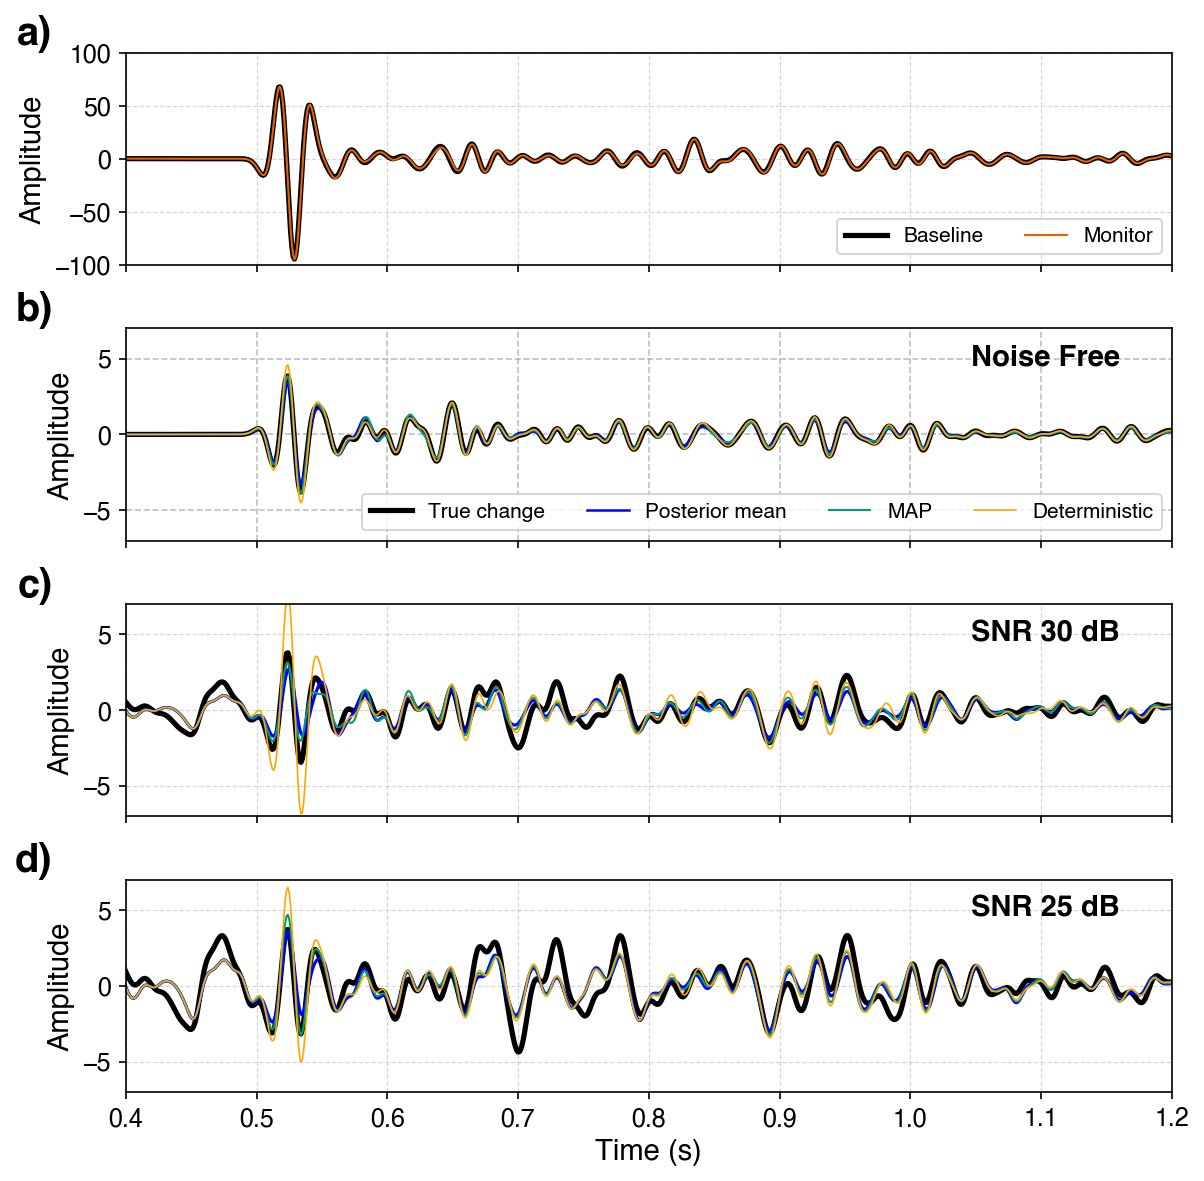

In [64]:
fig = plt.figure(figsize=(9, 9), dpi=150)
gs = gridspec.GridSpec(4, 1, hspace=0.3)
fontsize = 14

# (a) Baseline vs Monitor (clean)
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(t, dobs_bl_clean_trace, color='k', linewidth=2.5, label='Baseline')
ax1.plot(t, dobs_ml_clean_trace, color='#e66101', linewidth=1., label='Monitor')
ax1.set_xlim(0.4, 1.2)
ax1.set_ylim(-100, 100)
ax1.set_ylabel("Amplitude", fontsize=fontsize)
ax1.grid(linestyle='--', alpha=0.5, linewidth=0.6)
ax1.legend(fontsize=10, loc='lower right', ncol=2)
ax1.text(-0.07, 1.0, "a)", transform=ax1.transAxes, fontsize=19, fontweight="bold", va="bottom", ha="right")

# (b) Clean case
ax2 = fig.add_subplot(gs[1,0])
ax2.plot(t, dobs_ml_clean_trace - dobs_bl_clean_trace, color='k', linewidth=2.5, label='True change')
ax2.plot(t, dsyn_mean_clean_trace - dobs_bl_clean_trace, color='blue', linewidth=1.2, label='Posterior mean')
ax2.plot(t, dsyn_map_clean_trace - dobs_bl_clean_trace, color='#009E73', linestyle='-', linewidth=1.0, label='MAP')
ax2.plot(t, dsyn_fwi_clean_trace - dobs_bl_clean_trace, color='orange', linestyle='-', linewidth=0.8, label='Deterministic')
# ax2.fill_between(t, dsyn_p10_clean_trace - dobs_bl_clean_trace, dsyn_p90_clean_trace - dobs_bl_clean_trace, color='#fb9a99', alpha=0.75, label='P10-P90', edgecolor=None)
ax2.set_xlim(0.4, 1.2)
ax2.set_ylim(-7, 7)
ax2.set_ylabel("Amplitude", fontsize=fontsize)
ax2.grid(linestyle='--', alpha=0.8, linewidth=0.8)
ax2.legend(fontsize=10, loc='lower right', ncol=4)
ax2.text(-0.07, 1.0, "b)", transform=ax2.transAxes, fontsize=19, fontweight="bold", va="bottom", ha="right")
ax2.text(0.95, 0.8, "Noise Free", transform=ax2.transAxes, fontsize=fontsize, fontweight="bold", va="bottom", ha="right")

# (c) Noise case
ax3 = fig.add_subplot(gs[2,0])
ax3.plot(t, dobs_ml_noise_30_trace   - dobs_bl_noise_30_trace, color='k', linewidth=2.5, label='True waveform change')
ax3.plot(t, dsyn_mean_noise_30_trace - dobs_bl_noise_30_trace, color='blue', linewidth=1.5, label='Posterior mean')
ax3.plot(t, dsyn_map_noise_30_trace  - dobs_bl_noise_30_trace, color='#009E73', linestyle='-', linewidth=1.0, label='MAP')
ax3.plot(t, dsyn_fwi_noise_30_trace  - dobs_bl_noise_30_trace, color='orange', linestyle='-', linewidth=0.8, label='Deterministic')
# ax3.fill_between(t, dsyn_p10_noise_30_trace - dobs_bl_noise_30_trace, dsyn_p90_noise_30_trace - dobs_bl_noise_30_trace, color='#fb9a99', alpha=0.75, label='P10-P90', edgecolor=None)
ax3.set_xlim(0.4, 1.2)
ax3.set_ylim(-7, 7)
ax3.set_ylabel("Amplitude", fontsize=fontsize)
ax3.grid(linestyle='--', alpha=0.5, linewidth=0.6)
# ax3.legend(fontsize=10, loc='upper right', ncol=4)
ax3.text(-0.07, 1.0, "c)", transform=ax3.transAxes, fontsize=19, fontweight="bold", va="bottom", ha="right")
ax3.text(0.95, 0.8, "SNR 30 dB", transform=ax3.transAxes, fontsize=fontsize, fontweight="bold", va="bottom", ha="right")

# (d) Noise case
ax4 = fig.add_subplot(gs[3,0])
ax4.plot(t, dobs_ml_noise_25_trace   - dobs_bl_noise_25_trace, color='k', linewidth=2.5, label='True change')
ax4.plot(t, dsyn_mean_noise_25_trace - dobs_bl_noise_25_trace, color='blue', linewidth=1.5, label='Posterior mean')
ax4.plot(t, dsyn_map_noise_25_trace  - dobs_bl_noise_25_trace, color='#009E73', linestyle='-', linewidth=1.0, label='MAP')
ax4.plot(t, dsyn_fwi_noise_25_trace  - dobs_bl_noise_25_trace, color='orange', linestyle='-', linewidth=0.8, label='Deterministic')
# ax4.fill_between(t, dsyn_p10_noise_25_trace - dobs_bl_noise_25_trace, dsyn_p90_noise_25_trace - dobs_bl_noise_25_trace, color='#fb9a99', alpha=0.75, label='P10-P90', edgecolor=None)
ax4.set_xlim(0.4, 1.2)
ax4.set_ylim(-7, 7)
ax4.set_xlabel("Time (s)", fontsize=fontsize)
ax4.set_ylabel("Amplitude", fontsize=fontsize)
ax4.grid(linestyle='--', alpha=0.5, linewidth=0.6)
# ax4.legend(fontsize=11, loc='upper right', ncol=4)
ax4.text(-0.07, 1.0, "d)", transform=ax4.transAxes, fontsize=19, fontweight="bold", va="bottom", ha="right")
ax4.text(0.95, 0.8, "SNR 25 dB", transform=ax4.transAxes, fontsize=fontsize, fontweight="bold", va="bottom", ha="right")

ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax3.set_xticklabels([])
                
plt.tight_layout()
plt.savefig('figures/waveform.png', dpi=300, bbox_inches='tight')
plt.show()